# **Task 1 — Data Loading & Exploration**

# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


In [4]:
df = pd.read_csv("Housing.csv")

# Displaying first 10 rows

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# To check number of rows and columns

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


# Identify which column is target and which is feature

In [9]:
target = "price"
print("Target Column:", target)

Target Column: price


In [10]:
features = df.drop("price", axis=1)

print("Feature Columns:")
print(features.columns)

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


# Check for missing values in each column

In [11]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# **Task 2 — Data Cleaning**

Since there is no missing values so data cleaning is not needed

No. of duplicate rowa

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


# Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encodi

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

# Keep only the columns that are meaningful for predicting price

In [19]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


Task 3 — Model Building
# **New section**

In [20]:
X = df.drop("price", axis=1)
y = df["price"]

# Spliting the data

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Evaluate Linear Regression

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2 Score: 0.6529242642153184


# Train Random Forest Regressor

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest

In [25]:
print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


# **Task 4 – Visualization**

# Histogram showing distribution of house prices

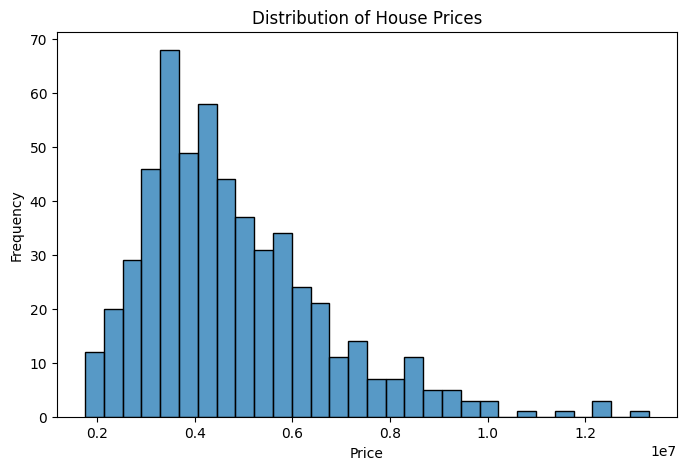

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.savefig('chart1_price_distribution.png')
plt.show()

# Correlation Heatmap

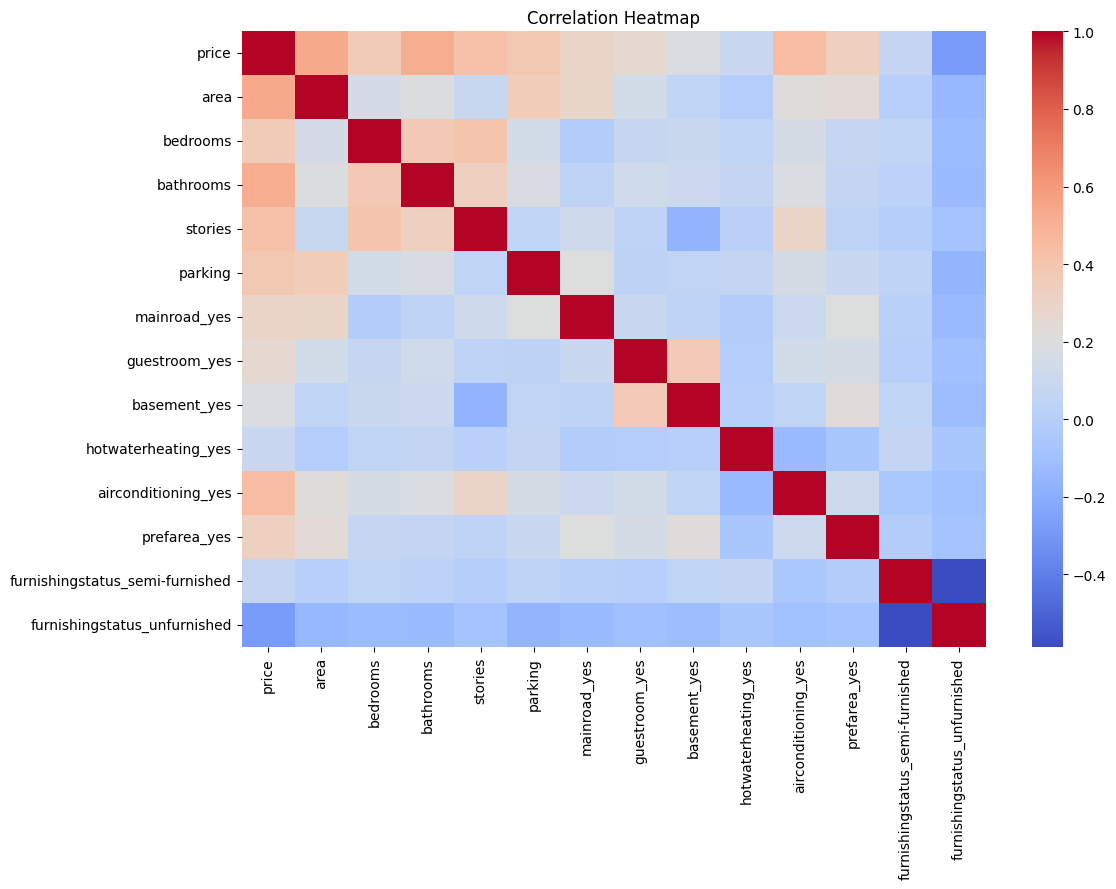

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=False, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.savefig('chart2_heatmap.png')
plt.show()

# Actual vs Predicted Price Scatter Plot

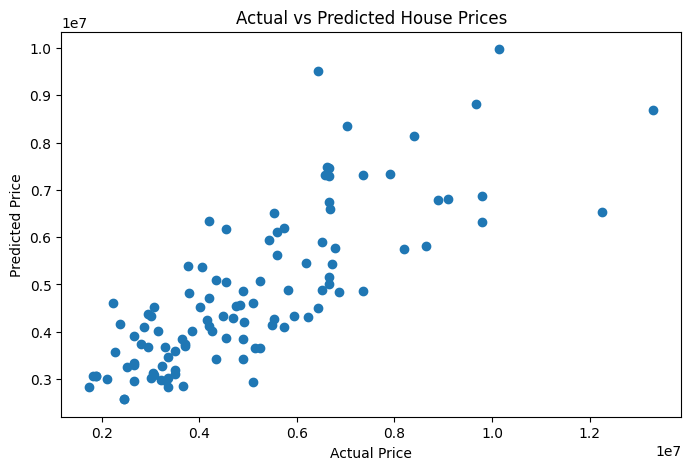

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.savefig('chart3_actual_vs_predicted.png')
plt.show()